# Event 02 — WTI 원유 마이너스 가격 사건 (2020-04-20)
## 스토리텔링 차트 (Scrollytelling Stepper)

### 배경
2020년 4월 20일, WTI 원유 5월물 선물이 사상 최초로 **마이너스 가격(-$37.63)**에 거래 종료. 실물 인수를 피하려는 투자자들이 돈을 얹어주고 계약을 던졌다.

### 4가지 디자인 원칙 (Event 1과 동일)
1. **점진적 공개 (Stepper)** — 프롤로그부터 Act 5까지 한 프레임씩
2. **축 분리** — WTI 가격 / 일일 변동 두 패널로 분리
3. **하이라이트 & 디밍** — 활성 국면만 진한 색
4. **용어 순화** — 기술적 선물 용어를 일반 언어로

### 출력
- `data/figures/e02_story/00_prologue.png` … `05_act5.png`
- `data/figures/e02_story/99_summary.png`

## 1. Imports & 경로 설정

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
WTI_PATH = ROOT / 'data' / 'raw' / 'WTI.csv'
FIG_DIR  = ROOT / 'data' / 'figures' / 'e02_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT     : {ROOT}')
print(f'FIG_DIR  : {FIG_DIR}')

ROOT     : c:\Users\kimch\Desktop\project\pandemic-finance
FIG_DIR  : c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story


## 2. 데이터 로드 & 전처리

`WTI.csv` 원본에서 2020-02-20 ~ 2020-05-05 구간만 추출. 일일 달러 변동 컬럼도 계산해 둔다.

In [2]:
wti = pd.read_csv(WTI_PATH, index_col=0, parse_dates=True)
wti.columns = ['WTI']
wti = wti.loc['2020-02-20':'2020-05-05'].dropna()
wti['WTI_change'] = wti['WTI'].diff()

print(f'shape : {wti.shape}')
print(f'min   : ${wti.WTI.min():.2f}  on  {wti.WTI.idxmin().date()}')
print(f'max   : ${wti.WTI.max():.2f}  on  {wti.WTI.idxmax().date()}')
print(f'max daily drop : ${wti.WTI_change.min():.2f}  on  {wti.WTI_change.idxmin().date()}')
wti.head(3)

shape : (53, 2)
min   : $-36.98  on  2020-04-20
max   : $53.77  on  2020-02-20
max daily drop : $-55.29  on  2020-04-20


,WTI,WTI_change
date,,
2020-02-20,53.77,NaN
2020-02-21,53.36,-0.41
2020-02-24,51.36,-2.00


## 3. 6국면 정의 — 이름·서사·핵심 주석

In [3]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 정상 유가',
        'start': '2020-02-20', 'end': '2020-03-05', 'color': '#64B5F6',
        'narrative': '코로나 이전 유가는 $50대 박스권에서 조용했다. 공급도 수요도 안정적이었다.',
        'hero_annotations': [
            ('2020-02-20', 53.77, '평상 유가 $54', (-55, 25), 'left'),
            ('2020-03-05', 45.90, '수요 둔화 조짐\n-14% (2주)', (-40, -40), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — OPEC+ 가격 전쟁',
        'start': '2020-03-06', 'end': '2020-03-13', 'color': '#FFB74D',
        'narrative': 'OPEC+ 추가 감산 협상이 결렬되자 사우디가 증산과 할인 공세로 가격 전쟁을 선포. 단 하루 만에 WTI는 -24.5% 폭락했다.',
        'hero_annotations': [
            ('2020-03-06', 41.14, 'OPEC+ 협상 결렬', (-80, 35), 'left'),
            ('2020-03-09', 31.05, '사우디 가격 전쟁\n-24.5% (하루)', (15, -35), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — 수요 절벽',
        'start': '2020-03-16', 'end': '2020-04-03', 'color': '#E57373',
        'narrative': '글로벌 락다운으로 항공·자동차·산업 수요가 통째로 증발. 공급은 여전한데 수요가 없으니 유가는 자유낙하해 3월 말 $14까지 추락했다.',
        'hero_annotations': [
            ('2020-03-23', 23.33, '글로벌 락다운 시작\n수요 -30%', (-55, 50), 'left'),
            ('2020-03-30', 14.10, '3월 저점 $14', (15, -30), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — 저장고 공포',
        'start': '2020-04-06', 'end': '2020-04-17', 'color': '#C62828',
        'narrative': 'OPEC+가 주말에 사상 최대 감산(-9.7백만 배럴/일)에 합의했지만, 미국 쿠싱 저장시설이 빠르게 차오르고 있었다. "원유를 둘 곳이 없다"는 공포가 시장을 지배했다.',
        'hero_annotations': [
            ('2020-04-13', 22.36, 'OPEC+ 역대 최대 감산\n(-9.7M b/d)', (-80, 50), 'left'),
            ('2020-04-17', 18.31, '쿠싱 저장고\n포화 경고', (-95, -40), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — 역사적 마이너스',
        'start': '2020-04-20', 'end': '2020-04-20', 'color': '#4A148C',
        'narrative': 'WTI 5월물 선물 만기일 — 실물 원유를 받을 수 없는 투자자들이 오히려 돈을 얹어주며 계약을 던졌다. 사상 최초로 원유 가격이 음수가 된 날.',
        'hero_annotations': [
            ('2020-04-20', -36.98, '⭐ -$37.63\n5월물 만기 · 사상 최초 마이너스', (25, 50), 'left'),
        ],
    },
    {
        'id': 'act5', 'name': 'Act 5 — 빠른 회복',
        'start': '2020-04-21', 'end': '2020-05-05', 'color': '#66BB6A',
        'narrative': '6월물로 계약이 롤오버되면서 유가는 즉시 양수로 복귀. 경제 재개 기대가 선반영되어 5월 초 $25선으로 반등했다.',
        'hero_annotations': [
            ('2020-04-21',  8.91, '6월물 롤오버\n+$45 반등', (20, 30), 'left'),
            ('2020-05-05', 24.56, '정상화 $25', (-40, 25), 'left'),
        ],
    },
]

pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 정상 유가,2020-02-20,2020-03-05,#64B5F6,코로나 이전 유가는 $50대 박스권에서 조용했다. 공급도 수요도 안정적이었다.
1,act1,Act 1 — OPEC+ 가격 전쟁,2020-03-06,2020-03-13,#FFB74D,OPEC+ 추가 감산 협상이 결렬되자 사우디가 증산과 할인 공세로 가격 전쟁을 선포...
2,act2,Act 2 — 수요 절벽,2020-03-16,2020-04-03,#E57373,글로벌 락다운으로 항공·자동차·산업 수요가 통째로 증발. 공급은 여전한데 수요가 없...
3,act3,Act 3 — 저장고 공포,2020-04-06,2020-04-17,#C62828,"OPEC+가 주말에 사상 최대 감산(-9.7백만 배럴/일)에 합의했지만, 미국 쿠싱..."
4,act4,Act 4 — 역사적 마이너스,2020-04-20,2020-04-20,#4A148C,WTI 5월물 선물 만기일 — 실물 원유를 받을 수 없는 투자자들이 오히려 돈을 얹...
5,act5,Act 5 — 빠른 회복,2020-04-21,2020-05-05,#66BB6A,6월물로 계약이 롤오버되면서 유가는 즉시 양수로 복귀. 경제 재개 기대가 선반영되어...


## 4. 공통 상수 & 헬퍼 함수

In [4]:
XLIM      = (pd.Timestamp('2020-02-20'), pd.Timestamp('2020-05-05'))
YLIM_WTI  = (-45, 65)
YLIM_CHG  = (-60, 15)
DIM_COLOR = '#D0D0D0'


def plot_wti_panel(ax, visible_end, phase):
    """WTI 가격 패널 — 디밍된 전체선 + 활성 구간 오버레이."""
    mask_v = wti.index <= visible_end
    xv = wti.index[mask_v]
    yv = wti['WTI'][mask_v]

    # 배경: 전체 디밍
    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.8, zorder=2)

    # 활성 구간 오버레이
    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    mask_a = (xv >= ps) & (xv <= pe)
    if mask_a.any():
        ax.plot(xv[mask_a], yv[mask_a], color=phase['color'], lw=3.2, zorder=5,
                marker='o', markersize=6, markerfacecolor=phase['color'],
                markeredgecolor='white', markeredgewidth=1.3)

    # $0 기준선
    ax.axhline(0, color='#555', linestyle='--', lw=1.3, alpha=0.85, zorder=1)
    ax.text(XLIM[1], 0.8, ' $0 기준선', ha='right', va='bottom',
            fontsize=9, color='#555', fontweight='bold')

    ax.set_ylabel('WTI 원유 가격 ($/배럴)', fontsize=11, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_chg_panel(ax, visible_end, phase):
    """일일 달러 변동 바 차트 — 활성 구간만 진한 색."""
    mask_v = wti.index <= visible_end
    xv = wti.index[mask_v]
    yv = wti['WTI_change'][mask_v]

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    mask_a = (xv >= ps) & (xv <= pe)

    for xi, yi, a in zip(xv, yv, mask_a):
        c = phase['color'] if a else DIM_COLOR
        alpha = 0.95 if a else 0.55
        ax.bar(xi, yi, width=0.8, color=c, alpha=alpha,
               edgecolor='white', lw=0.3, zorder=3)

    ax.axhline(0, color='#666', linestyle='-', lw=0.8, alpha=0.7, zorder=1)
    ax.set_ylabel('일일 변동 ($)', fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, axis='y', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def draw_frame(idx, show_future=False):
    """idx 번째 국면을 주인공으로 하는 프레임 생성 & 저장."""
    phase = phases[idx]
    phase_end = pd.Timestamp(phase['end'])
    visible_end = XLIM[1] if show_future else phase_end + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 2.2, 1.1], hspace=0.18)
    ax_rib = fig.add_subplot(gs[0])
    ax_wti = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_chg = fig.add_subplot(gs[2], sharex=ax_rib)

    # Ribbon
    for i, p in enumerate(phases):
        s = pd.Timestamp(p['start'])
        e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.95 if active else 0.18)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center',
                    fontsize=10.5 if active else 9,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    # Title & narrative
    fig.suptitle(f'[{idx+1}/6]  {phase["name"]}',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935, phase['narrative'],
             ha='center', va='top', fontsize=11.5, color='#333',
             style='italic', wrap=True)

    # Panels
    plot_wti_panel(ax_wti, visible_end, phase)
    plot_chg_panel(ax_chg, visible_end, phase)
    ax_wti.set_ylim(YLIM_WTI)
    ax_chg.set_ylim(YLIM_CHG)

    # 4/20 수직 강조선 (Act 4 이후)
    d420 = pd.Timestamp('2020-04-20')
    if d420 <= visible_end:
        alpha = 0.75 if idx >= 4 else 0.2
        for ax in (ax_wti, ax_chg):
            ax.axvline(d420, color='#4A148C', linestyle=':',
                       lw=1.6, alpha=alpha, zorder=2)

    # Hero annotations (WTI panel)
    for date, y, text, (dx, dy), ha in phase['hero_annotations']:
        d = pd.Timestamp(date)
        c = phase['color']
        ax_wti.scatter([d], [y], s=90, color=c, zorder=6,
                       edgecolors='white', lw=1.8)
        ax_wti.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=10,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.45', fc='white',
                                  ec=c, alpha=0.95, lw=1.2),
                        arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    # X축
    ax_chg.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_chg.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_chg.tick_params(axis='x', labelsize=9)
    ax_chg.set_xlabel('2020년', fontsize=10.5)
    for ax in (ax_rib, ax_wti):
        plt.setp(ax.get_xticklabels(), visible=False)

    # Footer
    fig.text(0.5, 0.01,
             'Data: FRED WTI (DCOILWTICO)   ·   회색 = 전체 기간 참고   ·   진한 색 = 현재 국면',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 5. 스토리 프레임 6장 순서대로 생성

C:\Users\kimch\AppData\Local\Temp\ipykernel_7140\586310922.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])


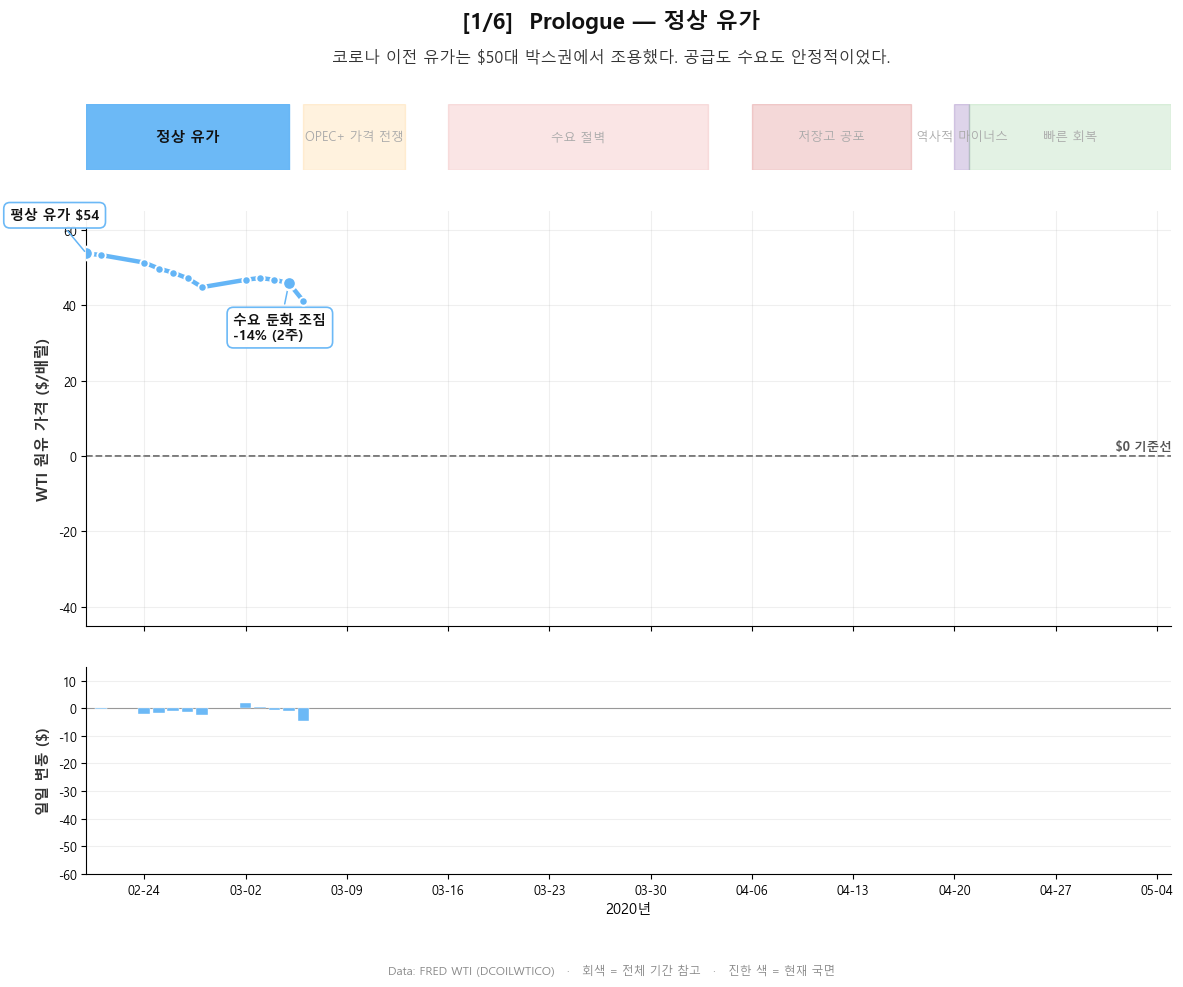

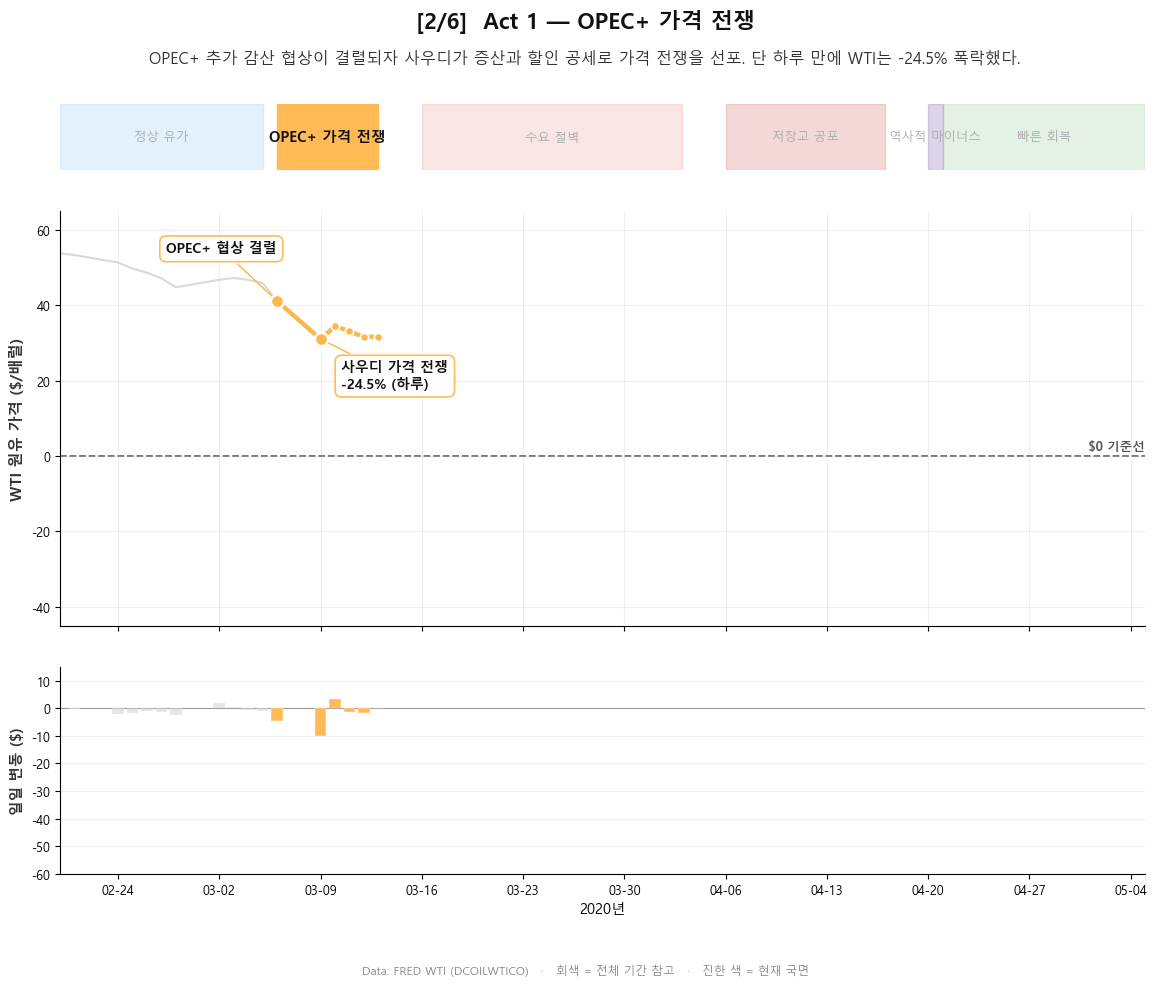

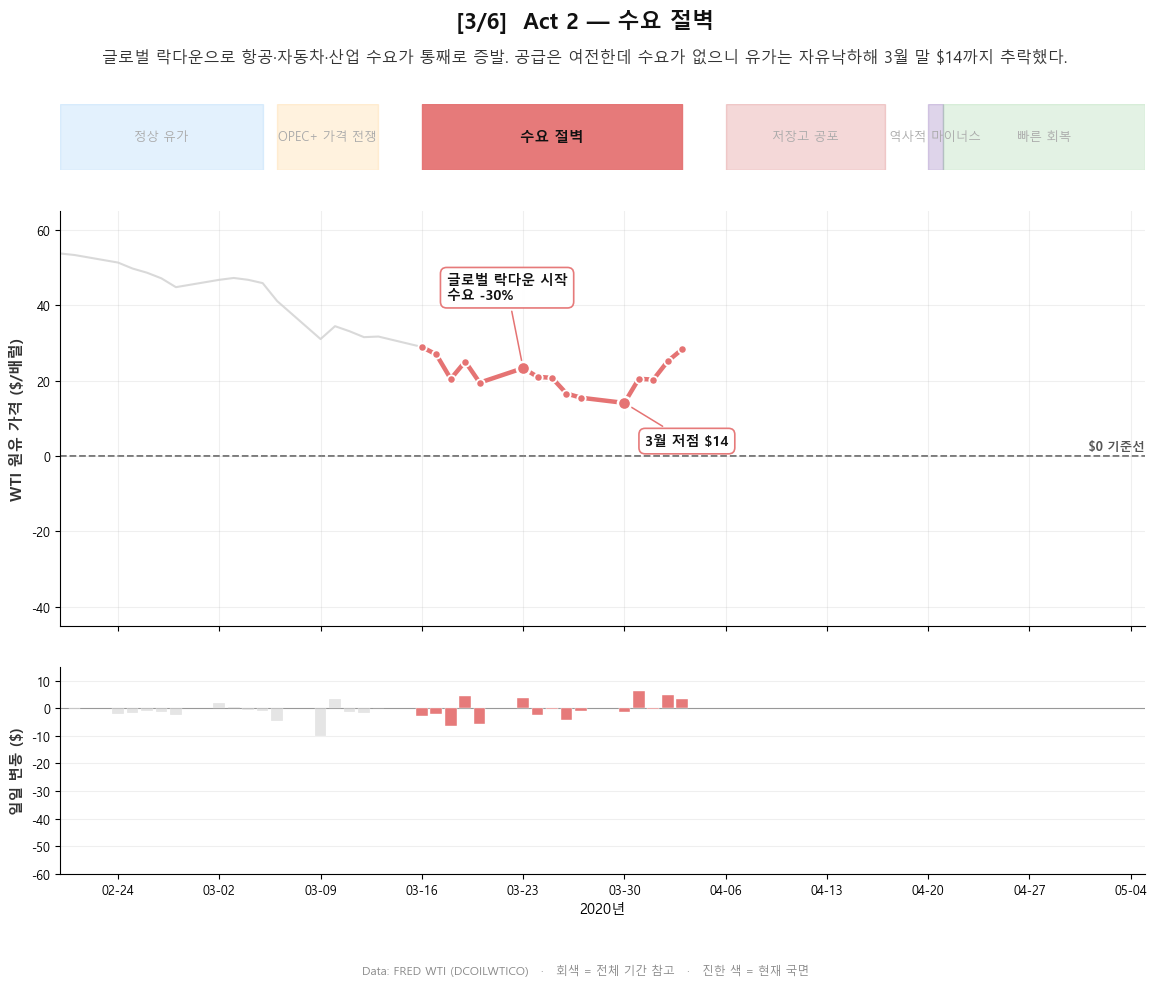

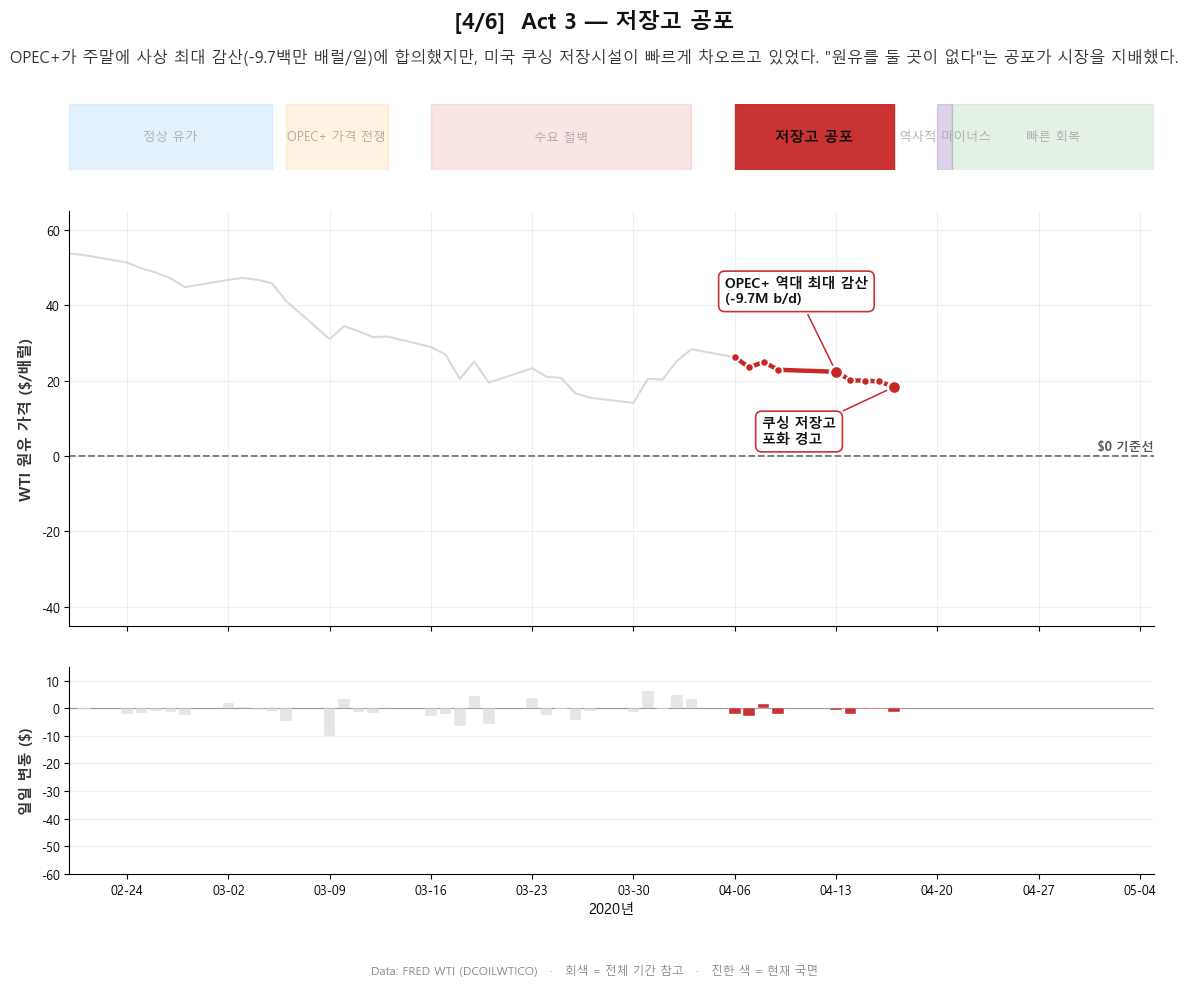

C:\Users\kimch\AppData\Local\Temp\ipykernel_7140\586310922.py:142: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
c:\Users\kimch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


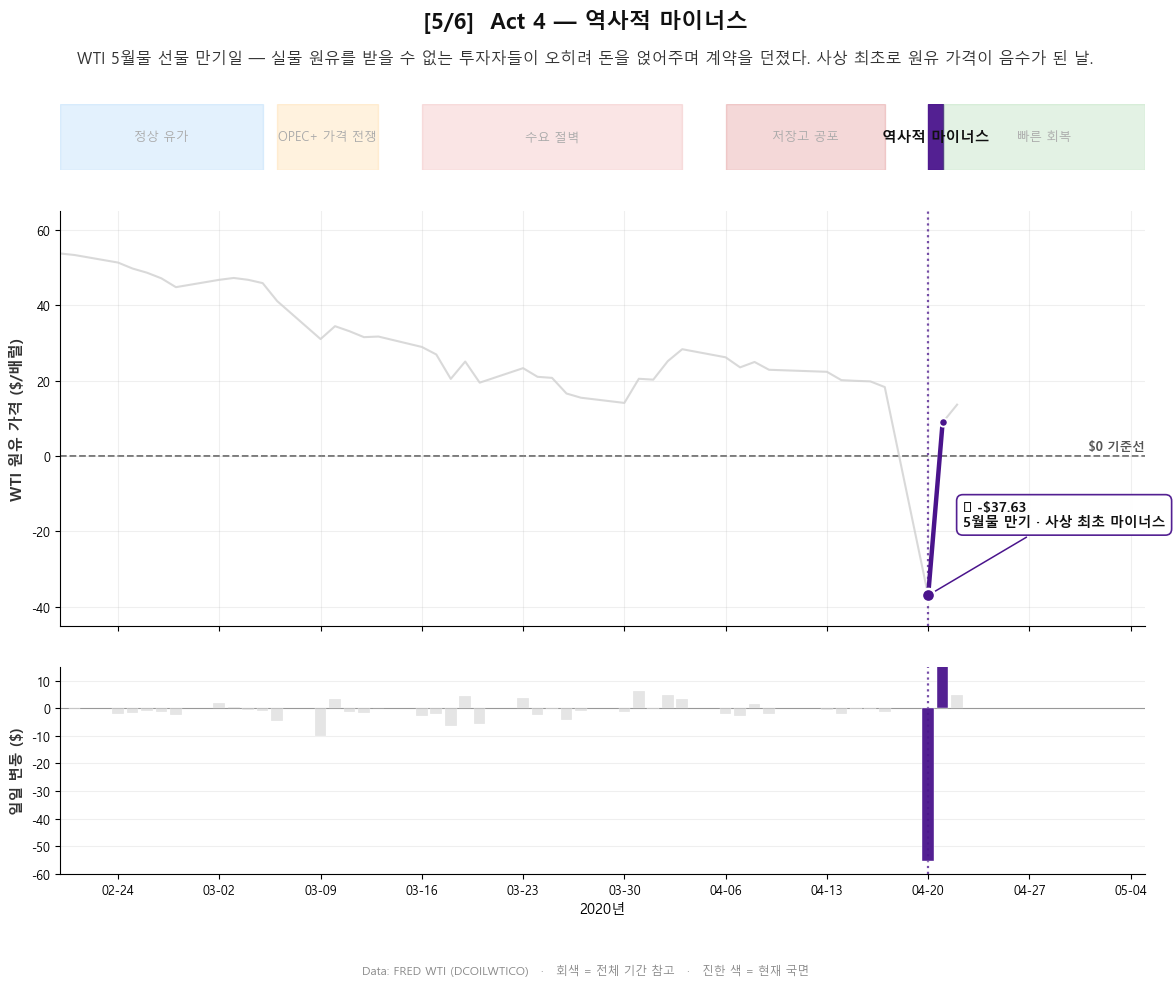

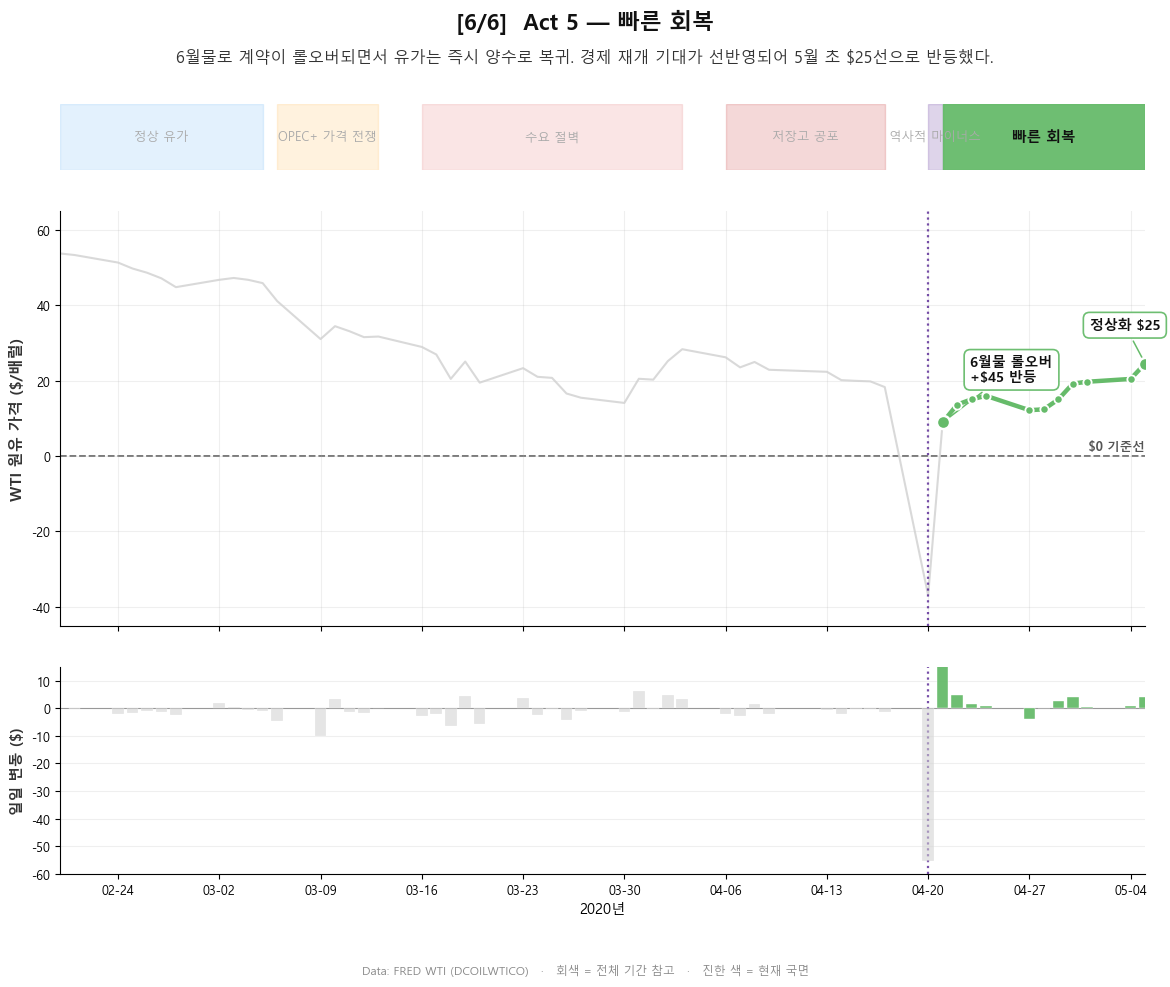


[OK] 저장된 프레임:
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story\04_act4.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story\05_act5.png


In [5]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()

print('\n[OK] 저장된 프레임:')
for p in saved:
    print(f'  - {p}')

## 6. 종합 프레임 — 모든 국면을 한 장으로

C:\Users\kimch\AppData\Local\Temp\ipykernel_7140\3246271764.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])
C:\Users\kimch\AppData\Local\Temp\ipykernel_7140\3246271764.py:95: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')


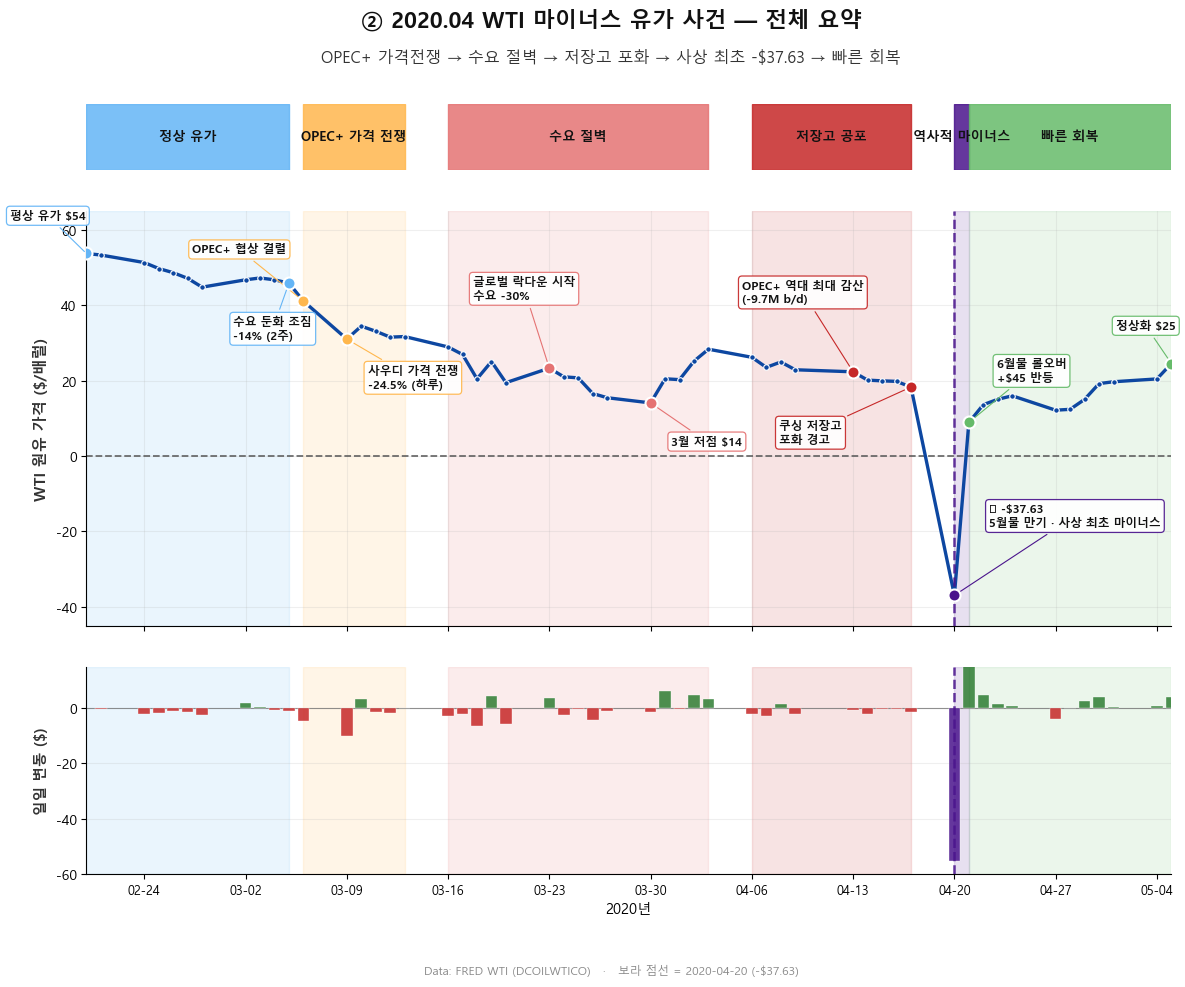


[OK] 종합 프레임: c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e02_story\99_summary.png


In [6]:
def draw_summary():
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 2.2, 1.1], hspace=0.18)
    ax_rib = fig.add_subplot(gs[0])
    ax_wti = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_chg = fig.add_subplot(gs[2], sharex=ax_rib)

    # Ribbon — 모든 국면 컬러풀
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.85)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center', fontsize=9.5,
                    fontweight='bold', color='#111')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle('\u2461 2020.04 WTI 마이너스 유가 사건 — 전체 요약',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935,
             'OPEC+ 가격전쟁 → 수요 절벽 → 저장고 포화 → 사상 최초 -$37.63 → 빠른 회복',
             ha='center', va='top', fontsize=11.5, color='#333', style='italic')

    # WTI panel - 국면별 배경 + 단일 색 실선
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        for ax in (ax_wti, ax_chg):
            ax.axvspan(s, e, color=p['color'], alpha=0.13, zorder=0)

    ax_wti.plot(wti.index, wti['WTI'], color='#0D47A1', lw=2.4,
                marker='o', markersize=4, markerfacecolor='#0D47A1',
                markeredgecolor='white', markeredgewidth=0.8, zorder=3)
    ax_wti.axhline(0, color='#555', linestyle='--', lw=1.3, alpha=0.85, zorder=2)
    ax_wti.set_ylabel('WTI 원유 가격 ($/배럴)', fontsize=11, fontweight='bold', color='#333')
    ax_wti.grid(alpha=0.2)

    # 일일 변동 바
    d420 = pd.Timestamp('2020-04-20')
    for xi, yi in zip(wti.index, wti['WTI_change']):
        if pd.isna(yi):
            continue
        c = '#4A148C' if xi == d420 else ('#C62828' if yi < 0 else '#2E7D32')
        ax_chg.bar(xi, yi, width=0.8, color=c, alpha=0.85,
                   edgecolor='white', lw=0.3, zorder=3)
    ax_chg.axhline(0, color='#666', linestyle='-', lw=0.8, alpha=0.7)
    ax_chg.set_ylabel('일일 변동 ($)', fontsize=10.5, fontweight='bold', color='#333')
    ax_chg.grid(alpha=0.2, axis='y')

    for ax in (ax_wti, ax_chg):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_wti.set_ylim(YLIM_WTI)
    ax_chg.set_ylim(YLIM_CHG)

    # 4/20 수직선
    for ax in (ax_wti, ax_chg):
        ax.axvline(d420, color='#4A148C', linestyle='--', lw=1.8, alpha=0.85, zorder=4)

    # 모든 hero annotations
    for phase in phases:
        for date, y, text, (dx, dy), ha in phase['hero_annotations']:
            d = pd.Timestamp(date)
            c = phase['color']
            ax_wti.scatter([d], [y], s=75, color=c, zorder=6,
                           edgecolors='white', lw=1.5)
            ax_wti.annotate(text, xy=(d, y), xytext=(dx, dy),
                            textcoords='offset points', fontsize=8.5,
                            fontweight='bold', ha=ha, color='#111',
                            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                                      ec=c, alpha=0.92, lw=0.9),
                            arrowprops=dict(arrowstyle='-', color=c, lw=0.8))

    ax_chg.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_chg.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_chg.tick_params(axis='x', labelsize=9)
    ax_chg.set_xlabel('2020년', fontsize=10.5)
    for ax in (ax_rib, ax_wti):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: FRED WTI (DCOILWTICO)   ·   보라 점선 = 2020-04-20 (-$37.63)',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out


fig, path = draw_summary()
plt.show()
print(f'\n[OK] 종합 프레임: {path}')

## 7. 최종 산출물 목록

In [ ]:
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.relative_to(ROOT)}   ({f.stat().st_size // 1024} KB)')